#Fashion-MNIST Image Classification using Fully Connected Neural Networks
##Project Overview

- This project investigates the performance of Fully Connected Neural Network(FCNNs) for classifying grayscale images from the Fashion-MNIST dataset.
- Rather than training a single model and reporting its accuracy, the project follows a systematic experimental workflow. A simple baseline model is first established, followed by a deeper FCNN and controlled experiments involving Dropouts, L2 regularization, and Learning-rate tuning.
- The objective is to understand how model architecture, regularization, and optimization choices affect classification performance and generalization.

### Key Areas of Investigation
- Exploratory data analysis and visualization
- Image preprocessing and normalization
- Baseline FCNN development
- Deep FCNN development
- Regularization using Dropout and L2 penalties
- Controlled learning-rate experimentation.
- Validation-based model selection
- Classification performance analysis
- Prediction confidence and calibration analysis
- Class-wise error analysis
- Training dynamics and overfitting
- Limitations of FCNNs for image classification
 ### Project Goal
 The final objective is to identify a well-performing and well -generalized FCNN while understanding the trade-offs between model complexity, regularization, and generalization.


## 1. Problem Statement
- Fashion-MNIST is a dataset of 70,000 grayscale images representing 10 categories of fashion items. Each image has a resolution of 28 x28 pixels.
- The objective of this project is to develop and evaluate Fully Connected Neural Network(FCNN) for multi-class image classification.
- The main challenge is to determine how far a fully connected architecture can perform on image data through controlled changes in network depth, regularization, and optimization, while maintaining good generalization to unseen data.



## 2. Project Objectives
The project aims to:

1. Understand the structure and class distribution of the Fashion-MNIST dataset.
2. Apply appropriate preprocessing for neural network training.
3. Establish a simple baseline model for performance comparision.
4. Develop a deeper Fully Connected Neural Network with increased representational capacity.
5. Investigate the effect of Dropout and L2 regularization on generalization.
6. Perform controlled hyperparameter experiments.
7. Select the best-performing model based on validation performance.
8. Evaluate the selected model on the unseen test dataset.
9. Analyze model errors and prediction confidence to understand failure cases.
10. Discuss the limitations of Fully Connected Neural Networks for image classification.


## 3. Evaluation Strategy

## 3. Evaluation Strategy
A three-way data strategy is used to prevent test-set leakage during model selection:
- Training Set - Used to learn model parameters.
- Validation Set - Used to compare different architectures, regularization techniques, and learning rates, and to select the final model.
- Test set : Kept completely unseen during experimentation and used only for the final evaluation.


Model performance is evaluated using:

- Accuracy
- Cross-entropy loss
- Confusion matrix
- Classification report
- Class-wise error rates
- Prediction confidence
- Calibration error (ECE)
- Training and validation curves

This evaluation strategy allows model performance to be assessed from both overall accuracy and detailed error-analysis perspectives.

## 4. Environment Setup and Reproducibility
The project is implemented in Python using TensorFlow/Keras for model development and Scikit-learn for evaluation and analysis.

A fixed random seed is used to improve reproducibility across experiments. The same preprocessing pipeline and evaluation strategy are maintained throughout the experiments so that model comparisons remain consistent.

### Libraries Used

- NumPy — numerical computation
- Matplotlib — visualization
- Seaborn — statistical and matrix visualization
- TensorFlow/Keras — neural network development and training
- Scikit-learn — data splitting and model evaluation
Why we're doing this

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [4]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Random seed:",SEED)

Random seed: 42


## 5. Dataset Loading and Initial Inspection
Fashion-MNIST is loaded using TensorFlow/Keras. The dataset contains grayscale images of fashion items belonging to 10 classes.

Before preprocessing, the dataset is inspected to verify:

- Training and test set dimensions
- Image resolution
- Pixel-value range
- Number of classes
- Label distribution

This initial inspection helps confirm that the dataset has been loaded correctly and provides a basic understanding of its structure before model training.

In [5]:
(X_train,y_train),(X_test,y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
print("Training image shape:", X_train.shape)
print("Training label shape:",y_train.shape)
print("Test image shape:",X_test.shape)
print("Test labels shape:", y_test.shape)

Training image shape: (60000, 28, 28)
Training label shape: (60000,)
Test image shape: (10000, 28, 28)
Test labels shape: (10000,)


In [7]:
print("\n Pixel value range:")
print("Minimum:", X_train.min())
print("Maximum:",X_train.max())
print("\nNumber of unique classes:",len(np.unique(y_train)))


 Pixel value range:
Minimum: 0
Maximum: 255

Number of unique classes: 10


## 6. Exploratory Data Analysis
Exploratory Data Analysis (EDA) is performed to understand the structure and characteristics of the Fashion-MNIST dataset before model training.

The analysis focuses on:

- Class distribution across the dataset
- Representative images from each fashion category
- Distribution of raw pixel values
- Presence of missing or invalid numerical values

These checks help identify potential data-quality issues and provide visual context for the classification task.

In [8]:
class_names= [
    "T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"
]

In [9]:
class_counts = np.bincount(y_train)

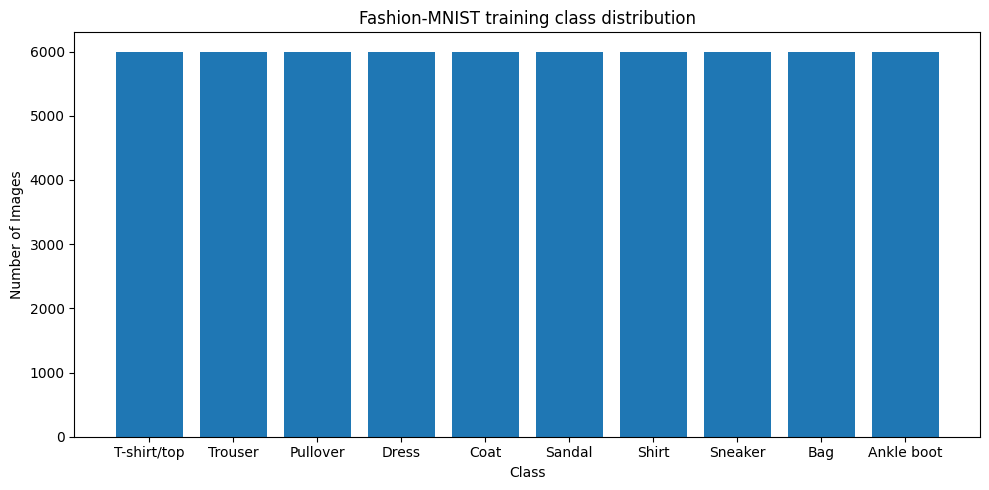

In [10]:
plt.figure(figsize=(10,5))
plt.bar(class_names,class_counts)
plt.title("Fashion-MNIST training class distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

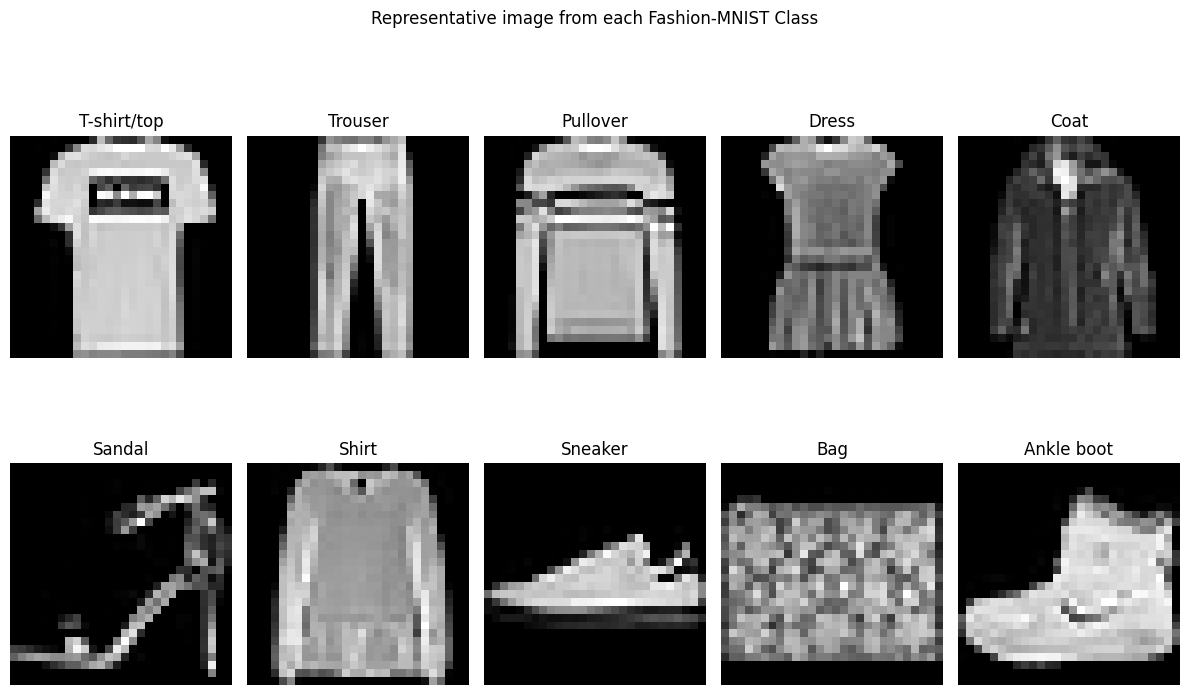

In [11]:
plt.figure(figsize=(12,8))
for i in range(10):
  image_index = np.where(y_train==i)[0][0]
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[image_index],cmap="gray")
  plt.title(class_names[i])
  plt.axis("off")
plt.suptitle("Representative image from each Fashion-MNIST Class")
plt.tight_layout()
plt.show()

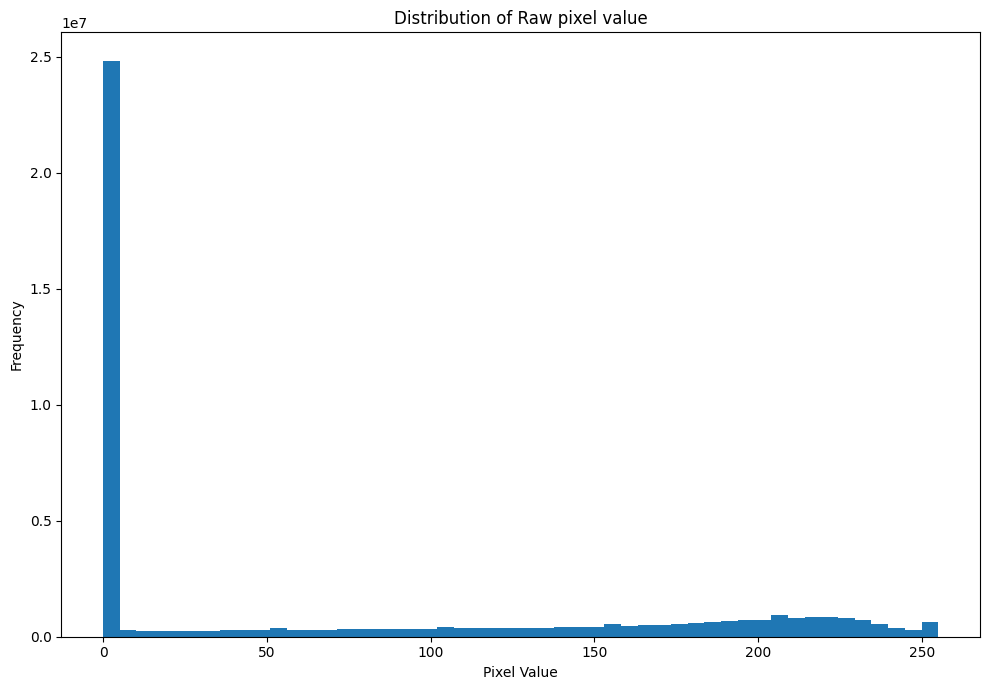

In [12]:
plt.figure(figsize=(10,7))
plt.hist(X_train.ravel(),bins=50)
plt.title("Distribution of Raw pixel value")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [13]:
print("NaN values in traing data:",np.isnan(X_train).sum())
print("NaN values in test data:",np.isnan(X_test).sum())
print("Infinite values in training data:", np.isinf(X_train).sum())
print("Infinite values in test data:",np.isinf(X_test).sum())
print("\nTraining data dtype:",X_train.dtype)
print("Test data dtype:",X_test.dtype)

NaN values in traing data: 0
NaN values in test data: 0
Infinite values in training data: 0
Infinite values in test data: 0

Training data dtype: uint8
Test data dtype: uint8


## 7. Data Preprocessing
The images are preprocessed before being provided to the neural networks.

### Preprocessing Steps

1. Pixel normalization: Pixel values are scaled from the original range of 0-255 to the range 0-1. This provides a more suitable numerical scale for neural network optimization.

2. Train-validation split: The original training data is divided into training and validation subsets. A stratified split is used so that the class distribution remains consistent across both subsets.

3. One-hot encoding: The integer class labels are converted into one-hot encoded vectors for compatibility with the softmax output layer and categorical cross-entropy loss.

4. Data validation: The processed arrays are checked for invalid values such as NaN or infinity before model training.

In [14]:
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [15]:
print("Training pixel range:",X_train.min(),"to",X_train.max())
print("Test pixel range:",X_test.min(),"to",X_test.max())

Training pixel range: 0.0 to 1.0
Test pixel range: 0.0 to 1.0


In [16]:
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val = train_test_split(
    X_train,y_train,test_size=0.10,random_state=SEED,stratify=y_train
)
print("Training Set:",X_train.shape,y_train.shape)
print("Validation set:", X_val.shape,y_val.shape)
print("Test set:", X_test.shape,y_test.shape)

Training Set: (54000, 28, 28) (54000,)
Validation set: (6000, 28, 28) (6000,)
Test set: (10000, 28, 28) (10000,)


In [17]:
y_train_encoded = tf.keras.utils.to_categorical(y_train,num_classes=10)
y_val_encoded = tf.keras.utils.to_categorical(y_val,num_classes=10)
y_test_encoded = tf.keras.utils.to_categorical(y_test,num_classes=10)

In [18]:
print("Encoded training labels:", y_train_encoded.shape)
print("Encoded validation labels:",y_val_encoded.shape)
print("Encoded test labels:", y_test_encoded.shape)

Encoded training labels: (54000, 10)
Encoded validation labels: (6000, 10)
Encoded test labels: (10000, 10)


In [19]:
print("NaN values:")
print("Train:",np.isnan(X_train).sum())
print("Validation:",np.isnan(X_val).sum())
print("Test:",np.isnan(X_test).sum())
print("\nInfinite values:")
print("Train:",np.isinf(X_train).sum())
print("Validation:",np.isinf(X_val).sum())
print("Test:",np.isinf(X_test).sum())

NaN values:
Train: 0
Validation: 0
Test: 0

Infinite values:
Train: 0
Validation: 0
Test: 0


## 8. Baseline Model
A baseline Fully Connected Neural Network (FCNN) is established as a reference model for the subsequent experiments.

The baseline uses a relatively simple architecture consisting of:

- Flatten layer to convert each 28 x 28 image into a one-dimensional feature vector
- One fully connected hidden layer with 128 neurons and ReLU activation
- Output layer with 10 neurons and softmax activation

The model is trained using stochastic gradient descent (SGD), categorical cross-entropy loss, and classification accuracy.

Early stopping is used during training to monitor validation loss and restore the best-performing model weights.

The baseline provides a performance reference against which deeper and regularized architectures can be compared.

In [20]:
baseline_model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(128,activation="relu"),
    Dense(10,activation="softmax")
])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

#Baseline Model Configuration
- The baseline uses the same loss function,optimizer,batch size, and training protocol that will be usedd in subsequent experiments whenever possible.
- This keeps the experiments comparable and allows performance difference to be attributed primarily to change in model architecture or regulatization.

In [21]:
baseline_model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Baseline Training
- Early stopping is used to prevent unnecessary training oncce validation performance stops improving.
- The best model weights are restored after training.


In [22]:
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience = 5,
    restore_best_weights=True
)
baseline_history = baseline_model.fit (
    X_train,y_train_encoded,validation_data=(X_val,y_val_encoded),epochs=50,batch_size=32,
    callbacks=[baseline_early_stopping],verbose=1
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7558 - loss: 0.7659 - val_accuracy: 0.8105 - val_loss: 0.5635
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8226 - loss: 0.5248 - val_accuracy: 0.8343 - val_loss: 0.4888
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8353 - loss: 0.4789 - val_accuracy: 0.8445 - val_loss: 0.4532
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8432 - loss: 0.4536 - val_accuracy: 0.8515 - val_loss: 0.4315
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8484 - loss: 0.4358 - val_accuracy: 0.8577 - val_loss: 0.4164
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8532 - loss: 0.4217 - val_accuracy: 0.8617 - val_loss: 0.4046
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8576 - loss: 0.4100 - val_accuracy: 0.8653 - val_loss: 0.3951
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8609 - loss: 0.4001 - 

In [23]:
baseline_val_loss,baseline_val_accuracy = baseline_model.evaluate(
    X_val,y_val_encoded,verbose=0
)
print(f"Baseline Validation Loss: {baseline_val_loss:.4f}")
print(f"Baseline Validation Accuracy: {baseline_val_accuracy:.4f}")

Baseline Validation Loss: 0.3011
Baseline Validation Accuracy: 0.8912


## 9. Deep Fully Connected Neural Network

To investigate whether greater model capacity improves classification performance, a deeper Fully Connected Neural Network is introduced.

The architecture contains three hidden layers:

- 512 neurons with ReLU activation
- 256 neurons with ReLU activation
- 128 neurons with ReLU activation
- 10-neuron softmax output layer

This model has substantially more trainable parameters than the baseline model, allowing it to learn more complex feature representations.

The model is trained using the same loss function, optimizer, batch size, and early-stopping strategy as the baseline wherever possible. This keeps the comparison focused primarily on the effect of increased network depth and capacity.

In [24]:
deep_model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(512,activation="relu"),
    Dense(256,activation="relu"),
    Dense(128,activation="relu"),
    Dense(10,activation="softmax")
])
deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
deep_model.compile(
    optimizer="sgd",loss="categorical_crossentropy",metrics=["accuracy"]
)

### Deep FCNN Training
- The deep FCNN is trained using the same training protocol as the baseline model.
- Using the same data split, optimizer, batch size, and early stopping stategy makes the comparison between the two architectures more meaningful.

In [26]:
deep_early_stopping = EarlyStopping(
    monitor="val_loss",patience=5,restore_best_weights=True
)
deep_history = deep_model.fit(
    X_train,y_train_encoded,validation_data=(X_val,y_val_encoded),
    epochs=50,batch_size=32,callbacks=[deep_early_stopping],
    verbose=1
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7572 - loss: 0.7277 - val_accuracy: 0.8178 - val_loss: 0.5148
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8303 - loss: 0.4786 - val_accuracy: 0.8435 - val_loss: 0.4408
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8469 - loss: 0.4296 - val_accuracy: 0.8563 - val_loss: 0.4050
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8574 - loss: 0.3991 - val_accuracy: 0.8655 - val_loss: 0.3849
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8653 - loss: 0.3767 - val_accuracy: 0.8710 - val_loss: 0.3698
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8714 - loss: 0.3586 - val_accuracy: 0.8752 - val_loss: 0.3572
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8776 - loss: 0.3431 - val_accuracy: 0.8802 - val_loss: 0.3468
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8815 - loss: 0

In [27]:
deep_val_loss, deep_val_accuracy = deep_model.evaluate(
    X_val,y_val_encoded,verbose=0
)
print(f"Deep FCNN Validation Loss:{deep_val_loss:.4f}")
print(f"Deep FCNN Validation Accuracy:{deep_val_accuracy:.4f}")

Deep FCNN Validation Loss:0.2909
Deep FCNN Validation Accuracy:0.8953


## 10. Baseline vs Deep FCNN Comparision

The baseline and deep FCNN are compared to determine whether increasing network capacity provides a meaningful improvement in validation performance.

The comparison considers:

- Number of trainable parameters
- Validation accuracy
- Validation loss

The purpose is not simply to identify the model with the highest accuracy, but to evaluate whether the additional model complexity provides a meaningful performance benefit.

In [28]:
comparison = {
    "Model":["Baseline","Deep FCNN"],
    "Parameters":[
        baseline_model.count_params(),
        deep_model.count_params()
    ],
    "Validation Accuracy":[
        baseline_val_accuracy,deep_val_accuracy
    ],
    "Validation Loss":[
        baseline_val_loss,deep_val_loss
    ]
}

In [29]:
for i in range(len(comparison["Model"])):
  print(f"\n{comparison["Model"][i]}")
  print(f"Parameters:{comparison["Parameters"][i]:,}")
  print(f"Validation Accuracy:{comparison["Validation Accuracy"][i]:.4f}")
  print(f"Validation Loss:{comparison["Validation Loss"][i]:.4f}")


Baseline
Parameters:101,770
Validation Accuracy:0.8912
Validation Loss:0.3011

Deep FCNN
Parameters:567,434
Validation Accuracy:0.8953
Validation Loss:0.2909


In [30]:
accuracy_improvement = deep_val_accuracy - baseline_val_accuracy
print(f"Baseline Validation Accuracy:{baseline_val_accuracy:.4f}")
print(f"Deep FCNN Validation Accuracy:{deep_val_accuracy:.4f}")
print(f"Accuracy Improvement:{accuracy_improvement:+.4f}")
print(f"Accuracy Improvement (% points): {accuracy_improvement*100:+.2f}")

Baseline Validation Accuracy:0.8912
Deep FCNN Validation Accuracy:0.8953
Accuracy Improvement:+0.0042
Accuracy Improvement (% points): +0.42


In [31]:
parameter_increase = (
    (deep_model.count_params()-baseline_model.count_params())/
    baseline_model.count_params()
)*100
print(f"Baseline Parameters:{baseline_model.count_params():,}")
print(f"Deep FCNN Parameters:{deep_model.count_params():,}")
print(f"Parameter Increase:{parameter_increase:.2f}%")

Baseline Parameters:101,770
Deep FCNN Parameters:567,434
Parameter Increase:457.57%


### Interpretation
The deeper FCNN increases the number of trainable parameters substantially compared with the baseline model. However, the improvement in validation accuracy is relatively small.

This indicates that simply increasing the depth and capacity of a fully connected network does not necessarily translate into a proportional improvement in performance on Fashion-MNIST.

This motivates the use of regularization techniques in the following experiments to determine whether better generalization can be achieved without relying only on additional model capacity.

## 11. Dropout Regularization Experiment
The previous experiment showed that increasing network capacity produced only a modest improvement in validation performance. This experiment investigates whether regularization can improve generalization.

Dropout is introduced into the deep FCNN by randomly deactivating a proportion of neurons during training. This reduces reliance on individual neurons and can help limit overfitting.

A dropout rate of 0.30 is applied after each hidden layer while keeping the underlying network architecture unchanged.

The model is trained and evaluated using the same validation-based approach as the previous experiments.

In [32]:
dropout_model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(512,activation="relu"),
    Dropout(0.30),
    Dense(256,activation="relu"),
    Dropout(0.30),
    Dense(128,activation="relu"),
    Dropout(0.30),
    Dense(10,activation="softmax")
])
dropout_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

### Dropout Configuration
The Dropout experiment uses the same three-hidden-layer architecture as the deep FCNN:

- 512 → 256 → 128 hidden units
- ReLU activation in hidden layers
- 30% Dropout after each hidden layer
- 10-unit softmax output layer
- SGD optimizer
- Categorical cross-entropy loss
- Early stopping based on validation loss

Keeping the architecture largely unchanged allows the effect of Dropout to be examined more directly.

In [33]:
dropout_model.compile(
    optimizer = "sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
dropout_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience =5,
    restore_best_weights=True
)

In [35]:
dropout_history = dropout_model.fit(
    X_train,y_train_encoded,
    validation_data=(X_val,y_val_encoded),
    epochs=50,batch_size=32,
    callbacks=[dropout_early_stopping],
    verbose=1
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.6534 - loss: 0.9702 - val_accuracy: 0.8023 - val_loss: 0.5560
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7867 - loss: 0.6049 - val_accuracy: 0.8387 - val_loss: 0.4612
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8138 - loss: 0.5298 - val_accuracy: 0.8523 - val_loss: 0.4166
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8286 - loss: 0.4862 - val_accuracy: 0.8605 - val_loss: 0.3901
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8398 - loss: 0.4567 - val_accuracy: 0.8663 - val_loss: 0.3734
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8474 - loss: 0.4343 - val_accuracy: 0.8693 - val_loss: 0.3625
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8517 - loss: 0.4181 - val_accuracy: 0.8755 - val_loss: 0.3456
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8579 - loss: 0

In [36]:
dropout_val_loss, dropout_val_accuracy = dropout_model.evaluate(
    X_val,y_val_encoded,verbose=0
)
print(f"Dropout Validation Loss: {dropout_val_loss:.4f}")
print(f"Dropout Validation Accuracy: {dropout_val_accuracy:.4f}")

Dropout Validation Loss: 0.2667
Dropout Validation Accuracy: 0.9042


## 12. L2 Regularization Experiment
L2 regularization is evaluated as an alternative approach to controlling model complexity and improving generalization.

L2 regularization adds a penalty proportional to the squared magnitude of the model weights to the training objective. This encourages the network to avoid excessively large weights.

The same three-hidden-layer architecture used in the deep FCNN is retained, with an L2 regularization coefficient of 0.0001 applied to the hidden-layer kernels.

The model is evaluated using the same validation-based methodology as the previous experiments.

In [37]:
l2_model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(
        512,activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.0001)
    ),
    Dense(
        256,activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.0001)
    ),
    Dense(128,activation="relu",
          kernel_regularizer=tf.keras.regularizers.l2(0.0001)
          ),
    Dense(10,activation="softmax")
])
l2_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

### L2 Regularization Configuration
The L2 experiment uses:

- 512 → 256 → 128 hidden units
- ReLU activation
- L2 regularization coefficient: 0.0001
- 10-unit softmax output layer
- SGD optimizer
- Categorical cross-entropy loss
- Early stopping based on validation loss

The architecture is kept consistent with the deep FCNN so that the experiment focuses on the effect of L2 regularization.


In [38]:
l2_model.compile(
    optimizer="sgd",loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
l2_early_stopping = EarlyStopping(
    monitor="val_loss",patience=5,
    restore_best_weights=True
)
l2_history = l2_model.fit(
    X_train,y_train_encoded,
    validation_data=(X_val,y_val_encoded),
    epochs=50,batch_size=32,
    callbacks=[l2_early_stopping],verbose=1
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7621 - loss: 0.8296 - val_accuracy: 0.8162 - val_loss: 0.6284
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8327 - loss: 0.5886 - val_accuracy: 0.8420 - val_loss: 0.5538
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8492 - loss: 0.5401 - val_accuracy: 0.8588 - val_loss: 0.5173
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8590 - loss: 0.5103 - val_accuracy: 0.8658 - val_loss: 0.4951
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8666 - loss: 0.4882 - val_accuracy: 0.8712 - val_loss: 0.4790
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8722 - loss: 0.4706 - val_accuracy: 0.8763 - val_loss: 0.4673
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8773 - loss: 0.4557 - val_accuracy: 0.8795 - val_loss: 0.4566
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8820 - loss: 0

In [40]:
l2_val_loss,l2_val_accuracy = l2_model.evaluate(
    X_val,y_val_encoded,verbose=0
)
print(f"L2 validation Loss:{l2_val_loss:.4f}")
print(f"L2 validation Accuracy:{l2_val_accuracy:.4f}")

L2 validation Loss:0.3965
L2 validation Accuracy:0.8963


## 13. Learning Rate Experiment
The learning rate controls the step size used by the optimizer when updating model weights.

To investigate its effect on training and validation performance, the Dropout-regularized FCNN is trained with a lower learning rate of 0.001 and compared with the original learning rate of 0.01.

The model architecture and Dropout configuration are kept unchanged so that the experiment isolates the effect of the learning rate.

Both configurations are evaluated using validation performance, with early stopping applied during training.

In [41]:
dropout_lr_model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(512,activation="relu"),
    Dropout(0.30),
    Dense(256,activation="relu"),
    Dropout(0.30),
    Dense(128,activation="relu"),
    Dropout(0.30),
    Dense(10,activation="softmax")
])

In [42]:
dropout_lr_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
dropout_lr_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
dropout_lr_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,restore_best_weights=True
)
dropout_lr_history = dropout_lr_model.fit(
    X_train,y_train_encoded,epochs=50,
    validation_data=(X_val,y_val_encoded),batch_size=32,verbose=1,
    callbacks=[dropout_lr_early_stopping]
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.3512 - loss: 1.8552 - val_accuracy: 0.6627 - val_loss: 1.1761
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5684 - loss: 1.2165 - val_accuracy: 0.6895 - val_loss: 0.8611
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.6357 - loss: 0.9970 - val_accuracy: 0.7223 - val_loss: 0.7587
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6726 - loss: 0.9004 - val_accuracy: 0.7420 - val_loss: 0.7009
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6986 - loss: 0.8337 - val_accuracy: 0.7622 - val_loss: 0.6597
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7175 - loss: 0.7889 - val_accuracy: 0.7790 - val_loss: 0.6252
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7301 - loss: 0.7552 - val_accuracy: 0.7883 - val_loss: 0.5994
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7441 - loss: 0

In [44]:
dropout_lr_val_loss,dropout_lr_val_accuracy = dropout_lr_model.evaluate(
    X_val,y_val_encoded,verbose=0
)
print(f"Learning Rate 0.001 Validation Loss: {dropout_lr_val_loss:.4f}")
print(f"Learning Rate 0.001 Validation Accuracy: {dropout_lr_val_accuracy:.4f}")

Learning Rate 0.001 Validation Loss: 0.3544
Learning Rate 0.001 Validation Accuracy: 0.8743


### Learning Rate Comparison
- The original Dropout model used the default SGD learning rate of 0.01, while he second model uses a learning rate of 0.001.
- Only the learning rate is changes so that its effect on validation performance can be evaluated independently.

In [45]:
print("Learning Rate Comparison")
print(
    f"SGD 0.01 - "
    f"Validation Accuracy: {dropout_val_accuracy:.4f}"
    )
print(
    f"SGD 0.001 - "
    f"Validation Accuracy: {dropout_lr_val_accuracy:.4f}"
)
learning_rate_improvement = (
    dropout_lr_val_accuracy - dropout_val_accuracy
)
print(
    f"\nAccuracy Difference:"
    f"{learning_rate_improvement:+.4f}"
)

Learning Rate Comparison
SGD 0.01 - Validation Accuracy: 0.9042
SGD 0.001 - Validation Accuracy: 0.8743

Accuracy Difference:-0.0298


In [46]:
print("Original Dropout learning rate:",
      float(dropout_model.optimizer.learning_rate.numpy()))

Original Dropout learning rate: 0.009999999776482582


In [47]:
print("New Dropout learning rate:",
      float(dropout_lr_model.optimizer.learning_rate.numpy()))

New Dropout learning rate: 0.0010000000474974513


In [48]:
print(
    "Original Dropout best validation accuracy:",
    max(dropout_history.history["val_accuracy"])
)
print("LR 0.001 best validation acuracy:",
      max(dropout_lr_history.history["val_accuracy"]))

Original Dropout best validation accuracy: 0.9066666960716248
LR 0.001 best validation acuracy: 0.8743333220481873


In [49]:
dropout_val_loss, dropout_val_accuracy = dropout_model.evaluate(
    X_val,
    y_val_encoded,
    verbose=0
)

dropout_lr_val_loss, dropout_lr_val_accuracy = dropout_lr_model.evaluate(
    X_val,
    y_val_encoded,
    verbose=0
)

print(f"Dropout (LR 0.01) Validation Accuracy: {dropout_val_accuracy:.4f}")
print(f"Dropout (LR 0.001) Validation Accuracy: {dropout_lr_val_accuracy:.4f}")

Dropout (LR 0.01) Validation Accuracy: 0.9042
Dropout (LR 0.001) Validation Accuracy: 0.8743


## 14. Experiment Results and Model Selection
The results from the baseline, deep FCNN, Dropout, L2 regularization, and learning-rate experiments are consolidated for comparison.

Model selection is based on validation accuracy because the validation set is used to estimate performance on unseen data during experimentation.

The test set is intentionally excluded from this stage to prevent test-set leakage.

The model with the strongest validation performance is selected as the final candidate for evaluation on the unseen test dataset.

In [50]:
experiments = [
    {
        "Model": "Baseline",
        "Parameters": baseline_model.count_params(),
        "Validation Accuracy": baseline_val_accuracy,
        "Validation Loss": baseline_val_loss
    },
    {
        "Model": "Deep FCNN",
        "Parameters": deep_model.count_params(),
        "Validation Accuracy": deep_val_accuracy,
        "Validation Loss": deep_val_loss
    },
    {
        "Model": "Deep FCNN + Dropout",
        "Parameters": dropout_model.count_params(),
        "Validation Accuracy": dropout_val_accuracy,
        "Validation Loss": dropout_val_loss
    },
    {
        "Model": "Deep FCNN + L2",
        "Parameters": l2_model.count_params(),
        "Validation Accuracy": l2_val_accuracy,
        "Validation Loss": l2_val_loss
    },
    {
        "Model": "Dropout + LR 0.001",
        "Parameters": dropout_lr_model.count_params(),
        "Validation Accuracy": dropout_lr_val_accuracy,
        "Validation Loss": dropout_lr_val_loss
    }
]

for experiment in experiments:
    print(
        f"{experiment['Model']:<25} "
        f"Parameters: {experiment['Parameters']:,} | "
        f"Val Accuracy: {experiment['Validation Accuracy']:.4f} | "
        f"Val Loss: {experiment['Validation Loss']:.4f}"
    )

Baseline                  Parameters: 101,770 | Val Accuracy: 0.8912 | Val Loss: 0.3011
Deep FCNN                 Parameters: 567,434 | Val Accuracy: 0.8953 | Val Loss: 0.2909
Deep FCNN + Dropout       Parameters: 567,434 | Val Accuracy: 0.9042 | Val Loss: 0.2667
Deep FCNN + L2            Parameters: 567,434 | Val Accuracy: 0.8963 | Val Loss: 0.3965
Dropout + LR 0.001        Parameters: 567,434 | Val Accuracy: 0.8743 | Val Loss: 0.3544


In [51]:
best_experiment = max(
    experiments,
    key=lambda x: x["Validation Accuracy"]
)
print("Best Model:")
print(best_experiment["Model"])
print(f"Validation Accuracy: {best_experiment["Validation Accuracy"]:.4f}")

Best Model:
Deep FCNN + Dropout
Validation Accuracy: 0.9042


## 15. Final Test Evaluation
After completing all experiments, the model selected using validation performance is evaluated once on the unseen test dataset.

This provides an unbiased estimate of how the selected model generalizes to data that was not used during training or model selection.

The final test accuracy and loss are reported as the primary performance measures for the selected FCNN.

In [52]:
final_test_loss, final_test_accuracy = dropout_model.evaluate(
    X_test,y_test_encoded,verbose=0
)
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy:{final_test_accuracy:.4f}")

Final Test Loss: 0.3172
Final Test Accuracy:0.8897


In [53]:
generalization_gap = dropout_val_accuracy - final_test_accuracy
print(f"Validation Accuracy: {dropout_val_accuracy:.4f}")
print(f"Test Accuracy:{final_test_accuracy:.4f}")
print(f"Generalization Gap: {generalization_gap:+.4f}")

Validation Accuracy: 0.9042
Test Accuracy:0.8897
Generalization Gap: +0.0145


## 16. Confusion Matrix
A confusion matrix is used to A confusion matrix is used to examine how the final model's predictions are distributed across the 10 Fashion-MNIST classes.

Each row represents the true class, while each column represents the predicted class. Correct predictions appear along the diagonal, while off-diagonal values represent misclassifications.

The matrix helps identify which fashion categories are most difficult for the model to distinguish from one another.

In [54]:
y_test_prob = dropout_model.predict(X_test,verbose=0)
y_test_pred = np.argmax(y_test_prob,axis=1)
print("Predictions generated:", y_test_pred.shape)

Predictions generated: (10000,)


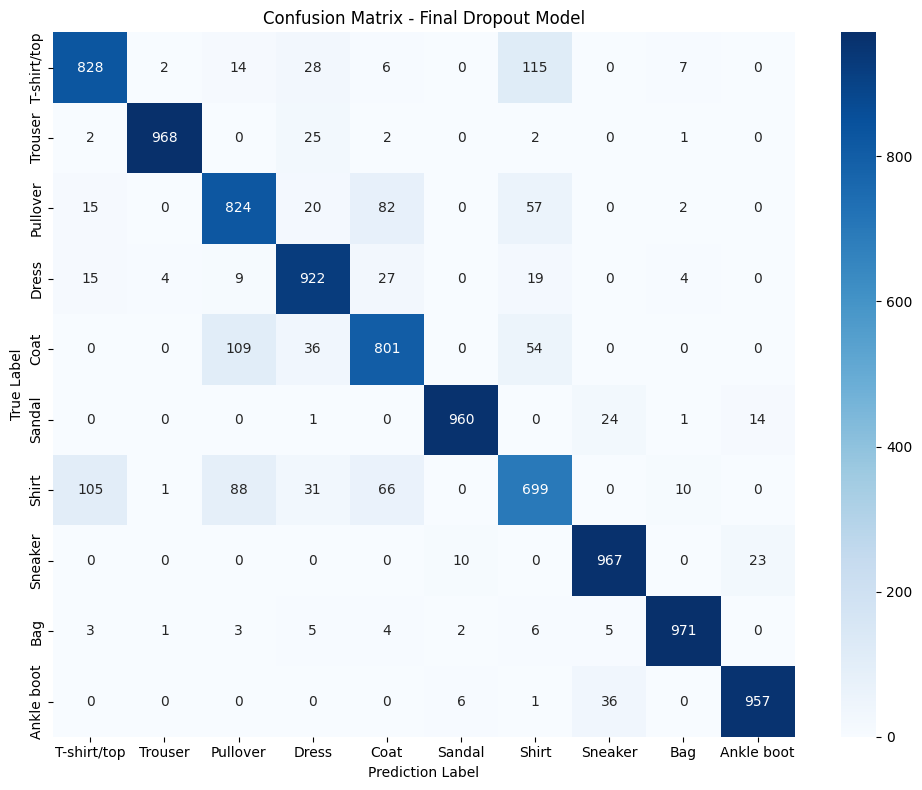

In [55]:
cm = confusion_matrix(y_test,y_test_pred)
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - Final Dropout Model")
plt.xlabel("Prediction Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 17. Classification Report
The classification report provides class-level performance metrics for the final model.

It includes:

- Precision
- Recall
- F1-score
- Support

These metrics provide more detailed information than overall accuracy and help identify whether the model performs consistently across all classes.

In [57]:
report = classification_report(
    y_test,y_test_pred,target_names=class_names,digits=4
)
print(report)

              precision    recall  f1-score   support

 T-shirt/top     0.8554    0.8280    0.8415      1000
     Trouser     0.9918    0.9680    0.9798      1000
    Pullover     0.7870    0.8240    0.8051      1000
       Dress     0.8633    0.9220    0.8917      1000
        Coat     0.8107    0.8010    0.8058      1000
      Sandal     0.9816    0.9600    0.9707      1000
       Shirt     0.7335    0.6990    0.7158      1000
     Sneaker     0.9370    0.9670    0.9518      1000
         Bag     0.9749    0.9710    0.9729      1000
  Ankle boot     0.9628    0.9570    0.9599      1000

    accuracy                         0.8897     10000
   macro avg     0.8898    0.8897    0.8895     10000
weighted avg     0.8898    0.8897    0.8895     10000



### Interpretation
The classification report provides a classs-wise view of model performance.
- Precision - Among images predicted as a class, how many were actually that class.
- Recall - Among all image belonging to a class, how many were correctly identified.
- F1-Score - Harmonic mean of precision and recall.
- Support - Number of test smaples belonging to each class.

The macro average treats all classes equally, while the weighted average accounts for the number of samples in each class.

## 18. Most Confused Class Pairs
The confusion matrix is further analyzed to identify the class pairs that contribute most to the model's misclassification errors.

For each pair of true and predicted classes, the number of incorrect predictions is examined and ranked.

This analysis provides a more focused view of the model's failure patterns and helps identify fashion categories with visually similar characteristics.

In [59]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors,0)
confusion_pairs = []
for true_class in range(len(class_names)):
  for predicted_class in range(len(class_names)):
    if true_class != predicted_class:
      confusion_pairs.append(
          (
              cm_errors[true_class,predicted_class],
              class_names[true_class],
              class_names[predicted_class]
          )
      )


In [60]:
confusion_pairs = sorted(
    confusion_pairs,key= lambda x: x[0],reverse=True
)

In [62]:
print("Top 10 Confusion Pairs")
print("-" *50)
for count,true_class,predicted_class in confusion_pairs[:10]:
  print(
      f"True: {true_class:<15} --"
      f"Predicted: {predicted_class:<15} |"
      f"Count: {count}"
  )

Top 10 Confusion Pairs
--------------------------------------------------
True: T-shirt/top     --Predicted: Shirt           |Count: 115
True: Coat            --Predicted: Pullover        |Count: 109
True: Shirt           --Predicted: T-shirt/top     |Count: 105
True: Shirt           --Predicted: Pullover        |Count: 88
True: Pullover        --Predicted: Coat            |Count: 82
True: Shirt           --Predicted: Coat            |Count: 66
True: Pullover        --Predicted: Shirt           |Count: 57
True: Coat            --Predicted: Shirt           |Count: 54
True: Coat            --Predicted: Dress           |Count: 36
True: Ankle boot      --Predicted: Sneaker         |Count: 36


#### Interpretation
The most frequent confusion pairs highlight where the FCNN struggles to distinguish between visually similar fashion categories.

These errors are expected to be more challenging for a fully connected architecture because the model receives flattened pixel values rather than explicitly modeling the spatial structure of the image.

The confusion-pair analysis therefore provides useful evidence for understanding the types of mistakes made by the final model.

## 19. Prediction Confidence Analysis
In addition to classification accuracy, the confidence of the model's predictions is analyzed.

For each test sample, the maximum predicted class probability is treated as the model's confidence. Predictions are then separated into correct and incorrect groups to examine how confidence relates to prediction correctness.

This analysis helps determine whether the model tends to assign lower confidence to uncertain predictions and whether it makes errors with unusually high confidence.

In [63]:
y_test_confidence = np.max(y_test_prob,axis=1)
correct_predictions = y_test_pred == y_test
incorrect_predictions = ~correct_predictions
print(f"Average confidence - Correct predictions:"
  f"{y_test_confidence[correct_predictions].mean():.4f}")
print(
    f"Average confidence - Incorrect predictions: "
    f"{y_test_confidence[incorrect_predictions].mean():.4f}"
)

Average confidence - Correct predictions:0.9394
Average confidence - Incorrect predictions: 0.6948


### Confidence Distribution
- The confidence distributions of correct and incorrect predictions are compared to understand how well model confidence reflects prediction correctness.

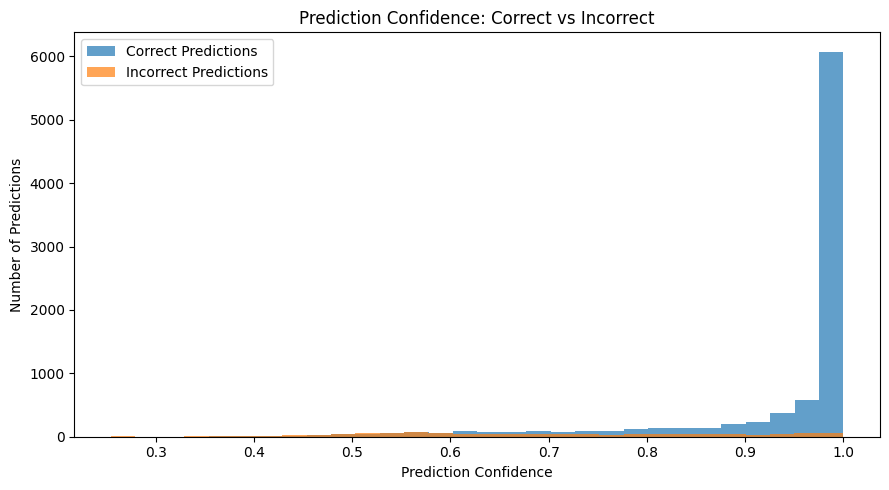

In [64]:
plt.figure(figsize=(9,5))
plt.hist(
    y_test_confidence[correct_predictions],bins=30,alpha=0.7,
    label="Correct Predictions"
)
plt.hist(
    y_test_confidence[incorrect_predictions],bins=30,alpha = 0.7,
    label="Incorrect Predictions"
)
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Predictions")
plt.title("Prediction Confidence: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

### Highly Confident Incorrect Predictions
Incorrect predictions with a confidence of at least 90% are examined separately.

These cases are particularly important because the model is highly certain despite producing an incorrect classification.

Visualizing these examples provides insight into difficult or ambiguous images and highlights cases where prediction confidence does not correspond to correctness.

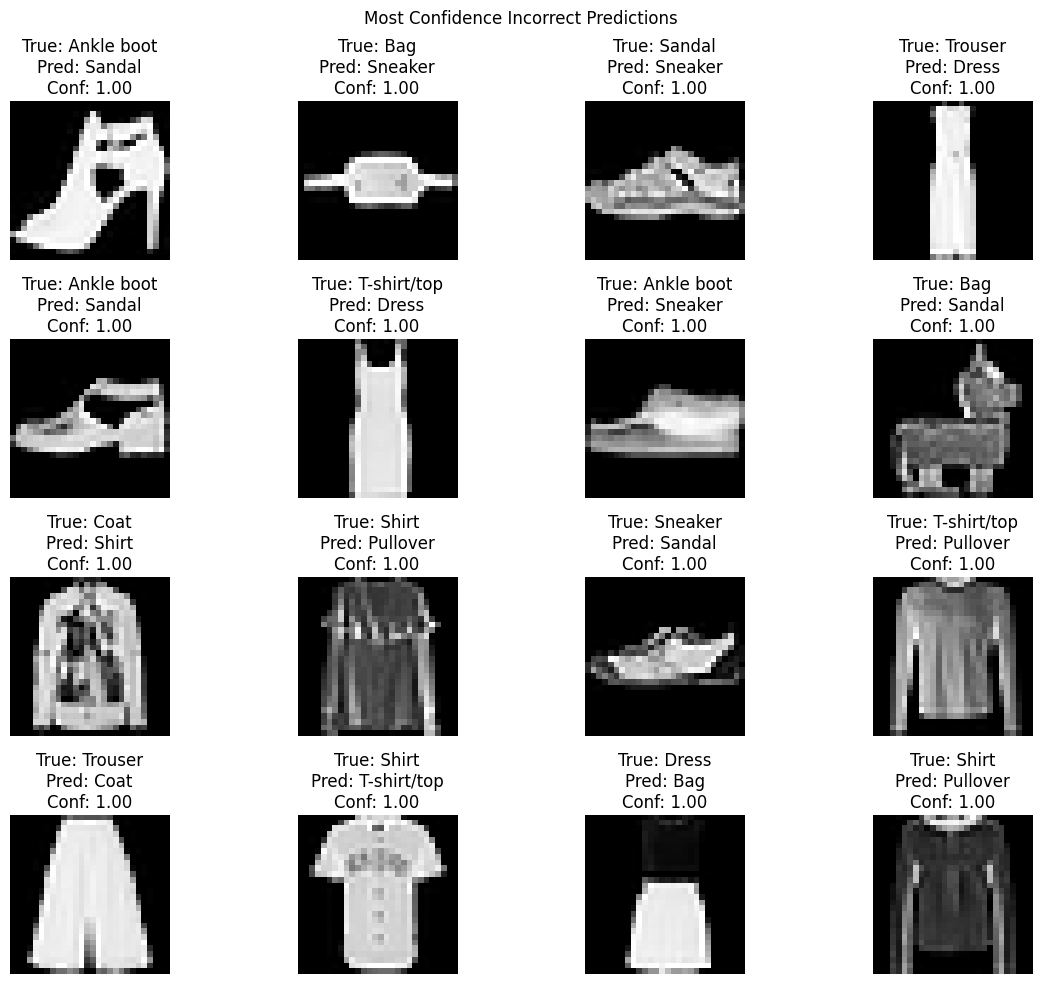

In [67]:
incorrect_indices = np.where(incorrect_predictions)[0]
sorted_error_indices = incorrect_indices[
    np.argsort(y_test_confidence[incorrect_indices])[::-1]
]
top_confident_errors = sorted_error_indices[:16]
plt.figure(figsize=(12,10))
for i, index in enumerate(top_confident_errors):
  plt.subplot(4,4,i+1)
  plt.imshow(X_test[index],cmap="gray")
  plt.title(
      f"True: {class_names[y_test[index]]}\n"
      f"Pred: {class_names[y_test_pred[index]]}\n"
      f"Conf: {y_test_confidence[index]:.2f}"
  )
  plt.axis("off")
plt.suptitle("Most Confidence Incorrect Predictions")
plt.tight_layout()
plt.show()

## 20. Confidence Calibration Analysis
- The previous analysis showed that the model can produce highly confident incorrect predictions.
- To investigate this behavior more systematically, prediction confidence is compared with actual predicted accuracy across different confidence ranges.
- This analysis helps determines whether the model's predicted probabilites are well calibarated.

In [70]:
high_confidence_threshold = 0.90
high_confidence_errors = (
    incorrect_predictions &
    (y_test_confidence >= high_confidence_threshold)
)
num_high_confidence_errors = high_confidence_errors.sum()
num_incorrect_predictions = incorrect_predictions.sum()
precentage_high_confidence_errors = (
    num_high_confidence_errors / num_incorrect_predictions
)*100
print(
    f"Incorrect predictions: {num_incorrect_predictions}"
)
print(
    f"Incorrect predictions with confidence >= 0.90:"
    f"{num_high_confidence_errors}"
)
print(
    f"Precentage of errors made with confidence >= 0.90:"
    f"{precentage_high_confidence_errors:.2f}%"
)

Incorrect predictions: 1103
Incorrect predictions with confidence >= 0.90:194
Precentage of errors made with confidence >= 0.90:17.59%


### Reliablilty Diagram
A reliability diagram is used to compare the model's predicted confidence with its observed accuracy.

Predictions are grouped into confidence intervals, and the average confidence within each interval is compared with the fraction of predictions that are actually correct.

A perfectly calibrated model would follow the diagonal reference line, indicating that predicted confidence closely matches observed accuracy.

This visualization helps identify whether the model is systematically overconfident or underconfident across different confidence levels.

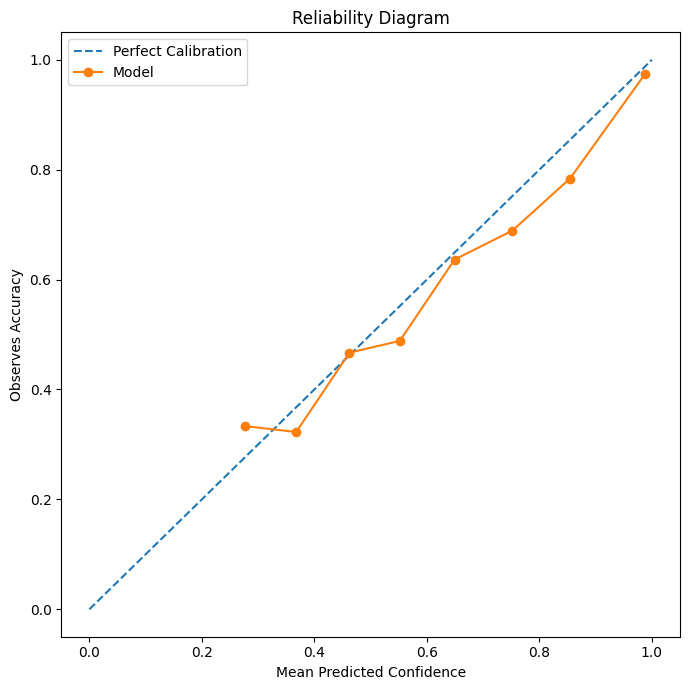

In [72]:
confidence_bins = np.linspace(0.0,1.0,11)
bin_accuracies = []
bin_confidences = []
bin_counts = []
for lower, upper in zip(
    confidence_bins[:-1],
    confidence_bins[1:]):
  if upper == 1.0:
    mask = (
        (y_test_confidence >= lower)&
        (y_test_confidence <= upper)
    )
  else:
    mask = (
        (y_test_confidence >= lower)&
        (y_test_confidence < upper)
    )
  count = mask.sum()
  if count> 0:
    bin_accuracy = correct_predictions[mask].mean()
    bin_confidence = y_test_confidence[mask].mean()
    bin_accuracies.append(bin_accuracy)
    bin_confidences.append(bin_confidence)
    bin_counts.append(count)
plt.figure(figsize=(7,7))
plt.plot(
    [0,1],[0,1],linestyle="--",label = "Perfect Calibration"
)
plt.plot(
    bin_confidences,bin_accuracies, marker="o",label="Model"
)
plt.xlabel("Mean Predicted Confidence")
plt.ylabel("Observes Accuracy")
plt.title("Reliability Diagram")
plt.legend()
plt.tight_layout()
plt.show()

## 21. Expected Calibration Error
Expected Calibration Error (ECE) provides a numerical summary of the difference between predicted confidence and observed accuracy across confidence bins.

A lower ECE indicates that the model's confidence estimates more closely match its actual prediction accuracy.

ECE is used alongside the reliability diagram to quantify calibration quality and provide a numerical complement to the visual analysis.

In [75]:
ece = 0.0
total_samples = len(y_test)
for lower,upper in zip(
    confidence_bins[:-1],confidence_bins[1:]
):
  if upper == 1.0:
    mask = (
        (y_test_confidence >= lower) & (y_test_confidence <= upper)
    )
  else:
    mask = (
        (y_test_confidence >= lower)&(y_test_confidence<upper)
    )
  bin_count = mask.sum()
  if bin_count > 0:
    bin_accuracy = correct_predictions[mask].mean()
    bin_confidence = y_test_confidence[mask].mean()
    ece +=(
        (bin_count/total_samples)*abs(bin_accuracy-bin_confidence)
    )
print(f"Expected Calibration Error(ECE):{ece:.4f}")

Expected Calibration Error(ECE):0.0230


### Calibration Interpretation
The final model achieves an ECE of approximately 0.023, indicating a relatively small overall difference between predicted confidence and observed accuracy.

However, a low average calibration error does not mean that every individual prediction is reliable. The presence of highly confident incorrect predictions shows that the model can still be overconfident on difficult examples.

Therefore, calibration should be considered alongside accuracy and detailed error analysis rather than as a standalone performance measure.

## 22. Class-Wise Error Analysis
Overall accuracy can hide differences in performance across individual classes.

Class-wise error analysis calculates the number and proportion of incorrect predictions for each true class. This helps identify categories for which the final FCNN has greater difficulty.

Understanding class-specific weaknesses provides a more detailed view of model behavior and complements the confusion matrix and classification report.

In [77]:
class_error_counts = []
for class_index, class_name in enumerate(class_names):
  class_mask = y_test == class_index
  total_samples = class_mask.sum()
  correct_samples = (
      y_test_pred[class_mask] == class_index
  ).sum()
  error_count = total_samples - correct_samples
  error_rate = error_count / total_samples
  class_error_counts.append(
      (
          class_name,total_samples,error_count, error_rate
      )
  )
class_error_counts = sorted(
    class_error_counts,key=lambda x: x[3],reverse=True
)
print("Class-wisee Error Analysis")
print("-"* 65)
for class_name, total, errors, error_rate in class_error_counts:
  print(
      f"{class_name:<15}"
      f"Total:{total:<5}"
      f"Errors:{errors:<5}"
      f"Error Rate: {error_rate:.2%}"
  )

Class-wisee Error Analysis
-----------------------------------------------------------------
Shirt          Total:1000 Errors:301  Error Rate: 30.10%
Coat           Total:1000 Errors:199  Error Rate: 19.90%
Pullover       Total:1000 Errors:176  Error Rate: 17.60%
T-shirt/top    Total:1000 Errors:172  Error Rate: 17.20%
Dress          Total:1000 Errors:78   Error Rate: 7.80%
Ankle boot     Total:1000 Errors:43   Error Rate: 4.30%
Sandal         Total:1000 Errors:40   Error Rate: 4.00%
Sneaker        Total:1000 Errors:33   Error Rate: 3.30%
Trouser        Total:1000 Errors:32   Error Rate: 3.20%
Bag            Total:1000 Errors:29   Error Rate: 2.90%


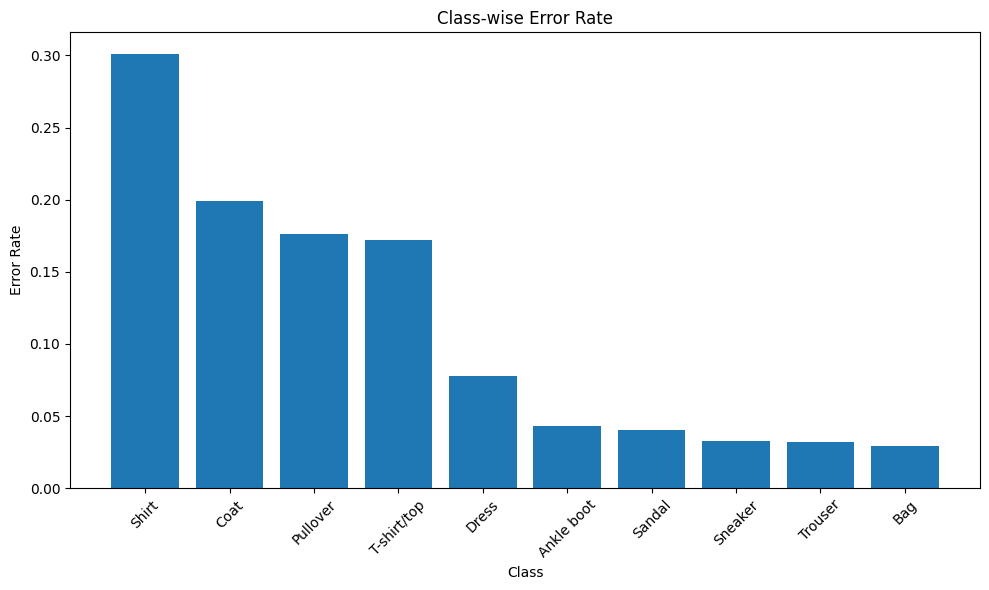

In [79]:
error_rates = [item[3] for item in class_error_counts]
error_labels = [item[0] for item in class_error_counts]
plt.figure(figsize=(10,6))
plt.bar(error_labels,error_rates)
plt.xlabel("Class")
plt.ylabel("Error Rate")
plt.title("Class-wise Error Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation
The class-wise error analysis shows that classification performance is not uniform across all Fashion-MNIST categories.

Classes with higher error rates are likely to contain greater visual similarity to other categories, making them more difficult to distinguish using a fully connected architecture.

These class-specific patterns complement the confusion matrix and provide additional evidence about the model's main failure modes.

## 23. Training Dynamics and Overfitting Analysis
Training and validation curves are analyzed to understand how model performance changes across epochs.

The analysis focuses on:

- Training versus validation accuracy
- Training versus validation loss
- Best validation epoch
- Total number of training epochs before early stopping

These curves help determine whether the model is learning effectively, underfitting, or beginning to overfit the training data.

Examining these dynamics also provides insight into how early stopping contributes to the final model's generalization.

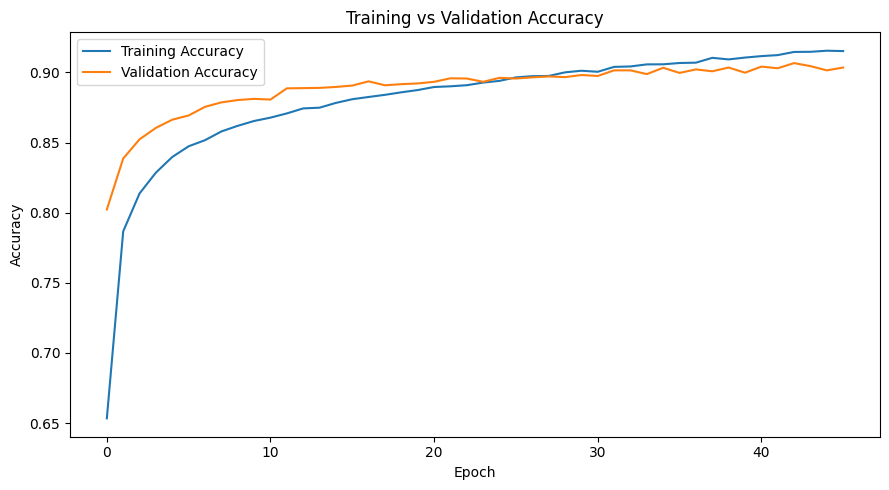

In [80]:
plt.figure(figsize=(9,5))
plt.plot(
    dropout_history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    dropout_history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

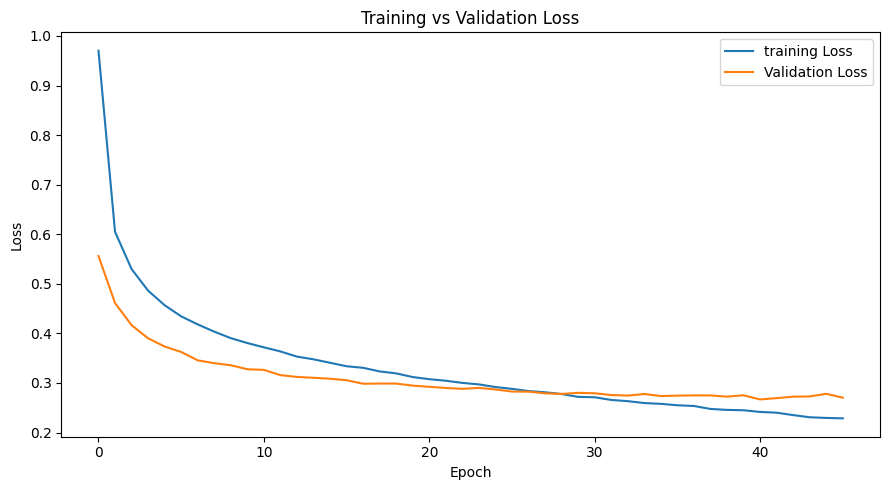

In [81]:
plt.figure(figsize=(9,5))
plt.plot(
    dropout_history.history["loss"],
    label="training Loss"
)
plt.plot(
    dropout_history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
best_epoch = np.argmax(
    dropout_history.history["val_accuracy"]
)+1
total_epochs = len(
    dropout_history.history["loss"]
)
best_val_accuracy = max(
    dropout_history.history["val_accuracy"]
)
print(f"Total epochs trained: {total_epochs}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best validation epoch: {best_epoch}")

Total epochs trained: 46
Best validation accuracy: 0.9067
Best validation epoch: 43


### Training Dynamics Interpretation
The training curves provide evidence about the model's learning behavior and generalization during training.

The final model achieves strong validation performance while maintaining a relatively small gap between validation and test accuracy. Early stopping also helps prevent unnecessary training after validation performance stops improving.

The curves therefore support the conclusion that the selected Dropout model generalizes reasonably well, although some degree of overfitting remains.

## 24. Model Limitations
Although the final FCNN achieves strong performance on Fashion-MNIST, the architecture has several important limitations.

### Loss of Spatial Information

The Flatten layer converts each 28 × 28 image into a one-dimensional vector. Although the network can learn from the pixel values, it does not explicitly preserve local spatial relationships in the way convolutional layers do.

### High Parameter Count

Fully connected layers can require a large number of parameters as input resolution or network width increases. This can increase computational cost and the risk of overfitting.

### Limited Image Representation

FCNNs can learn useful representations, but they are not specifically designed to capture local visual patterns such as edges, textures, and shapes.

### Limited Real-World Generalization

Fashion-MNIST consists of small, centered grayscale images and is considerably simpler than real-world fashion imagery. Performance on this dataset should therefore not be interpreted as equivalent performance on higher-resolution or more varied image classification tasks.

These limitations motivate the use of Convolutional Neural Networks (CNNs) for more advanced image-classification problems.

## 25. Final Results and Key Findings
The experiments demonstrate that both model architecture and regularization affect the performance and generalization of FCNNs.

### Key Findings

- The baseline FCNN achieved approximately 89.12% validation accuracy.
- Increasing the network depth improved validation accuracy to approximately 89.82%, while substantially increasing the number of trainable parameters.
- The Dropout-regularized FCNN achieved the strongest validation performance at approximately 90.67%.
- The L2-regularized model achieved approximately 89.78% validation accuracy and did not outperform the Dropout model in this configuration.
- Reducing the SGD learning rate from 0.01 to 0.001 resulted in lower validation performance, with the lower-learning-rate experiment achieving approximately 87.43% validation accuracy.
- The selected Dropout model achieved approximately 88.97% test accuracy on the unseen test dataset.
- The final model made 1,103 incorrect predictions out of 10,000 test samples.
- Among these errors, 194 predictions were made with confidence of at least 90%, demonstrating that high confidence does not always imply correctness.
- The final model achieved an ECE of approximately 0.023, indicating relatively good overall calibration.

Overall, the experiments show that adding regularization through Dropout provided a more meaningful improvement than simply increasing network depth. The results also demonstrate the importance of evaluating not only accuracy, but also generalization, error patterns, prediction confidence, and calibration.

### 26. Save Final Model
The selected Dropout-regularized FCNN is saved in Keras format so that the trained model can be reused without retraining.

Saving the trained model supports reproducibility and allows it to be loaded later for inference, further analysis, or integration into future applications.

In [100]:
dropout_model.save("fashion_mnist_fcnn_dropout.keras")
print("Final Model Saved Sucessfully")

Final Model Saved Sucessfully


## 27. Final Model Inference Demo
The saved final model is loaded and used to generate a prediction for a sample test image.

The inference workflow demonstrates how the trained FCNN can be reused to:

1. Select an input image.
2. Generate class probabilities.
3. Identify the predicted class.
4. Compare the prediction with the true class.
5. Report the model's confidence.

This provides a simple end-to-end demonstration of using the trained model for inference.

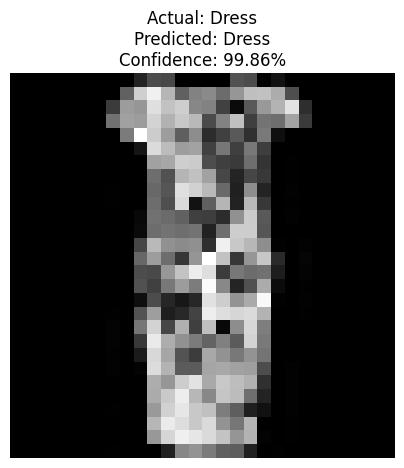

In [101]:
sample_index = 100
sample_image = X_test[sample_index]
sample_label = y_test[sample_index]
sample_input = np.expand_dims(sample_image,axis=0)
sample_probabilites = dropout_model.predict(
    sample_input,verbose=0
)
predicted_class = np.argmax(sample_probabilites[0])
predicted_confidence = np.max(sample_probabilites[0])
plt.figure(figsize=(5,5))
plt.imshow(sample_image,cmap="gray")
plt.title(
    f"Actual: {class_names[sample_label]}\n"
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {predicted_confidence:.2%}"
)
plt.axis("off")
plt.show()

## 28. Conclusion
This project evaluated Fully Connected Neural Networks for Fashion-MNIST classification through a structured series of experiments.

A baseline FCNN was first established, followed by a deeper architecture and controlled experiments with Dropout, L2 regularization, and learning-rate tuning. The results showed that increasing model capacity alone produced only a modest improvement, while Dropout provided a more substantial gain in validation performance.

The selected Dropout model achieved approximately **89.07% test accuracy**, with a relatively small generalization gap and an ECE of approximately **0.023**. Detailed error and confidence analysis also showed that the model can remain highly confident on some incorrect predictions.

The project demonstrates that systematic experimentation, validation-based model selection, and detailed error analysis provide more insight than reporting a single accuracy value.

At the same time, the limitations of FCNNs for image data highlight the potential benefits of convolutional architectures, which explicitly model local spatial patterns and are better suited to more complex visual tasks.

## 29. Final Experiment Summary

In [102]:
print("="*50)
print("Final Experiment Summary")
print("="*50)
print(f"{"Model":<28}{"Parameters":>12}{"Val Acc":>10}")
print("-"*50)
for experiment in experiments:
  print(
      f"{experiment["Model"]:<28}"
      f"{experiment["Parameters"]:>12,}"
      f"{experiment["Validation Accuracy"]:>10.2%}"
  )
print("-"*50)
print(f"Final Test Accuracy: {final_test_accuracy:.2%}")
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"ECE: {ece:.4f}")

Final Experiment Summary
Model                         Parameters   Val Acc
--------------------------------------------------
Baseline                         101,770    89.12%
Deep FCNN                        567,434    89.53%
Deep FCNN + Dropout              567,434    90.42%
Deep FCNN + L2                   567,434    89.63%
Dropout + LR 0.001               567,434    87.43%
--------------------------------------------------
Final Test Accuracy: 88.97%
Final Test Loss: 0.3172
ECE: 0.0230


## 30. Project Snapshot

### Dataset
- Fashion-MNIST
- 70,000 grayscale images
- 10 classes
- 28 × 28 pixel resolution

### Final Model
- Fully Connected Neural Network
- Architecture: 512 → 256 → 128 → 10
- Dropout: 30% after each hidden layer
- Optimizer: SGD
- Learning rate: 0.01
- Early stopping based on validation loss

### Final Performance
- Validation Accuracy: approximately 90.67%
- Test Accuracy: approximately 88.97%
- Test Loss: approximately 0.3172
- Generalization Gap: approximately 1.45 percentage points
- Expected Calibration Error: approximately 0.0230
- Incorrect Test Predictions: 1,103
- Highly Confident Errors: 194
- High-Confidence Error Rate: 17.59%

### Experiments Performed
- Baseline FCNN
- Deep FCNN
- Dropout regularization
- L2 regularization
- Learning-rate experiment
- Validation-based model selection

### Analysis Performed
- Exploratory data analysis
- Model comparison
- Confusion matrix
- Classification report
- Most confused class pairs
- Prediction confidence analysis
- Reliability diagram
- Expected Calibration Error
- Class-wise error analysis
- Training dynamics and overfitting analysis
- Final model inference

In [103]:
print("=" * 70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)

# --------------------------------------------------
# Validation Performance
# --------------------------------------------------

print(
    f"Baseline Validation Accuracy : "
    f"{max(baseline_history.history['val_accuracy']):.2%}"
)

print(
    f"Deep FCNN Validation Accuracy: "
    f"{max(deep_history.history['val_accuracy']):.2%}"
)

print(
    f"Dropout Validation Accuracy  : "
    f"{max(dropout_history.history['val_accuracy']):.2%}"
)

print(
    f"L2 Validation Accuracy       : "
    f"{max(l2_history.history['val_accuracy']):.2%}"
)

print(
    f"Dropout LR=0.001 Accuracy    : "
    f"{max(dropout_lr_history.history['val_accuracy']):.2%}"
)

print("-" * 70)

# --------------------------------------------------
# Final Test Performance
# --------------------------------------------------

print(f"Final Test Accuracy          : {final_test_accuracy:.2%}")
print(f"Final Test Loss              : {final_test_loss:.4f}")
print(f"Generalization Gap           : {generalization_gap:.2%}")
print(f"Expected Calibration Error   : {ece:.4f}")

print("-" * 70)

# --------------------------------------------------
# True Labels
# --------------------------------------------------

# Convert one-hot encoded test labels to class indices
# if necessary.
if y_test.ndim > 1:
    true_labels = np.argmax(y_test, axis=1)
else:
    true_labels = y_test

# --------------------------------------------------
# Prediction Errors
# --------------------------------------------------

incorrect_mask = y_test_pred != true_labels

incorrect_test_predictions = np.sum(incorrect_mask)

print(
    f"Incorrect Test Predictions   : "
    f"{incorrect_test_predictions:,}"
)

# --------------------------------------------------
# Prediction Confidence
# --------------------------------------------------

confidence = np.max(y_test_prob, axis=1)

high_confidence_threshold = 0.90

high_confident_errors = (
    incorrect_mask &
    (confidence >= high_confidence_threshold)
)

high_conf_error_count = np.sum(high_confident_errors)

# Calculate percentage of all incorrect predictions
if incorrect_test_predictions > 0:
    high_conf_error_percentage = (
        high_conf_error_count /
        incorrect_test_predictions
    ) * 100
else:
    high_conf_error_percentage = 0.0

print(
    f"Highly Confident Errors      : "
    f"{high_conf_error_count:,}"
)

print(
    f"High-Confidence Error Rate   : "
    f"{high_conf_error_percentage:.2f}%"
)

print("=" * 70)

FINAL MODEL PERFORMANCE SUMMARY
Baseline Validation Accuracy : 89.12%
Deep FCNN Validation Accuracy: 89.82%
Dropout Validation Accuracy  : 90.67%
L2 Validation Accuracy       : 89.78%
Dropout LR=0.001 Accuracy    : 87.43%
----------------------------------------------------------------------
Final Test Accuracy          : 88.97%
Final Test Loss              : 0.3172
Generalization Gap           : 1.45%
Expected Calibration Error   : 0.0230
----------------------------------------------------------------------
Incorrect Test Predictions   : 1,103
Highly Confident Errors      : 194
High-Confidence Error Rate   : 17.59%
